**Run Sim files before using the Notebook!** \
This Notebook constructs the plots related to the infidelity and the gamma overhead after the csv. files are constructed by the simulation files inside thesis/sim

In [264]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [265]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [266]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, FuncFormatter
import numpy as np
import seaborn as sns

**Overhead-Factor/ Physical Error Probability**

In [267]:
# Modify Plots to be IN latex Sytle
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
})

# Plot Style
DIST_STYLE = {
    3: {'color': 'tab:blue',   'marker': 'o'},
    5: {'color': 'tab:orange', 'marker': 'v'},
    7: {'color': 'tab:green',  'marker': '*'},
    9: {'color': 'tab:red',    'marker': 's'},
}

# Define Sci plotter for later use in all plots
def sci_format(x, pos):
    # This takes the number, divides by 1e-3, and formats it nicely
    # -> Need to be done since the formatting is shit otherwise
    return rf"${x / 1e-3:g} \times 10^{{-3}}$"

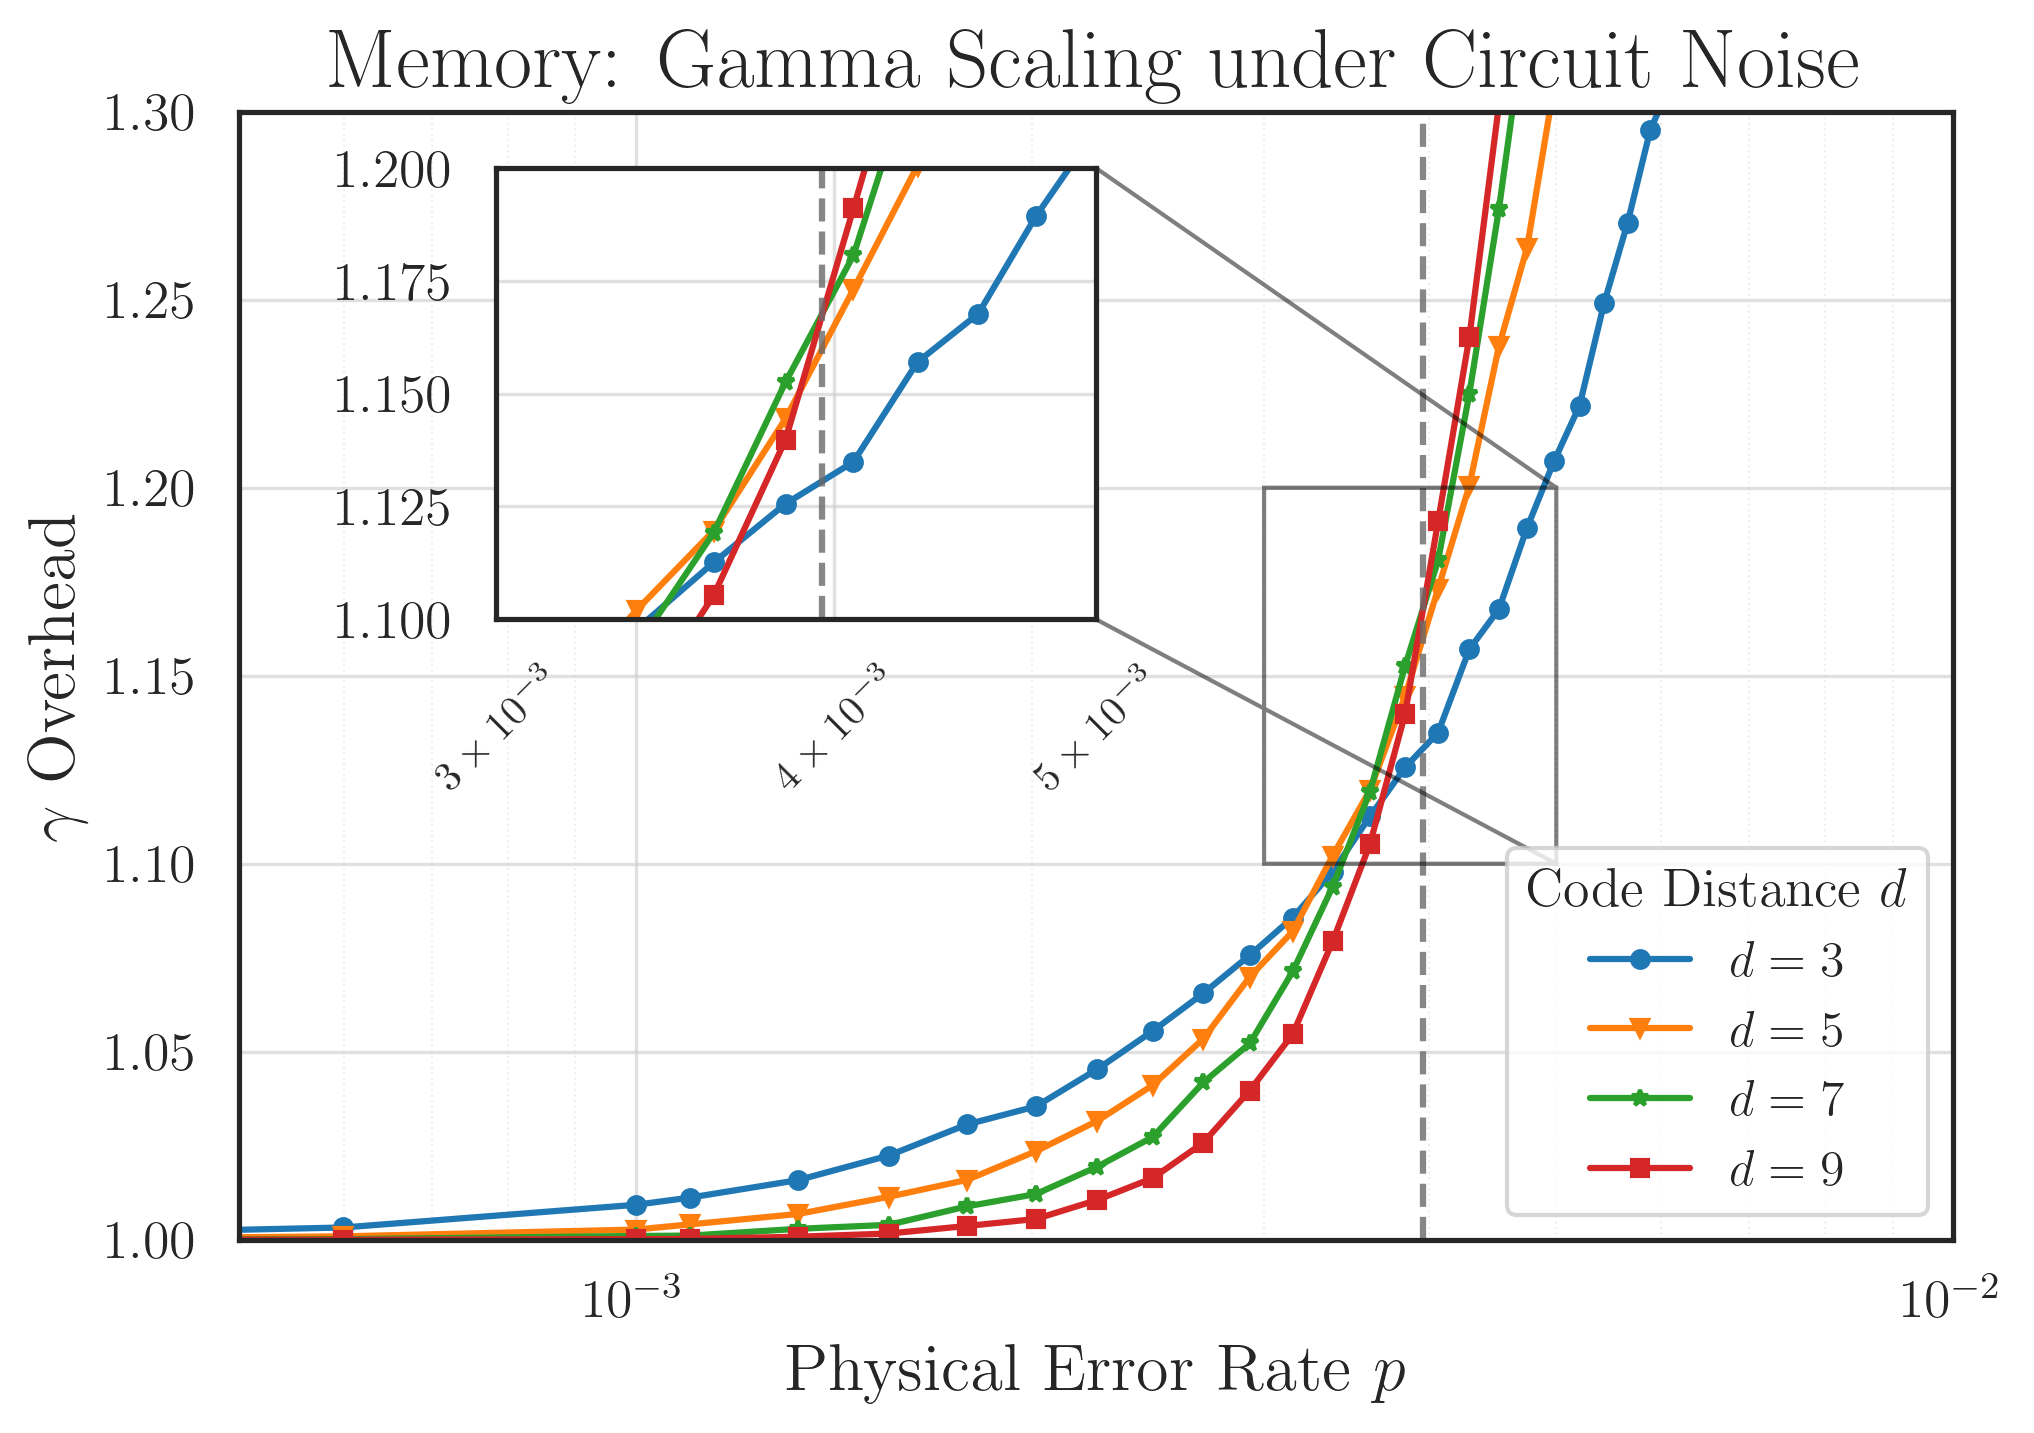

In [268]:
# Define the threshold
THRESHOLD_P = 3.96e-3

# 1. Load the data
df = pd.read_csv('../data/gamma_memory.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        **DIST_STYLE[distance],
        markersize=4,
        label=rf"$d={distance}$",
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 1.3)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(LogFormatterMathtext()) 
ax.set_title("Memory: Gamma Scaling under Circuit Noise", fontsize=20)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"$\gamma$ Overhead")

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend kept in the lower right
ax.legend(title="Code Distance $d$", loc='lower right')

# 4. Inset Plot for the Threshold Zoom
# Placed in the upper left [x0, y0, width, height]
# x starts at 5% from the left, y starts at 55% from the bottom
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the data onto the inset axes
for distance, group in df.groupby('distance'):
    axins.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        **DIST_STYLE[distance],
        markersize=4,
        label=rf"$d={distance}$",
    )

# Formatting the inset
axins.set_xscale('log')
axins.set_xticks([3e-3, 4e-3, 5e-3])
axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())
axins.tick_params(axis='x', rotation=45, labelsize=10)

# Zoomed limits for x (around p = 4e-3)
axins.set_xlim(3e-3, 5e-3)

# Note: You may need to tweak this y-limit slightly depending on 
# the exact gamma values near the threshold crossing.
axins.set_ylim(1.1, 1.2) 

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_memory_d3579.pdf", bbox_inches='tight')

plt.show()

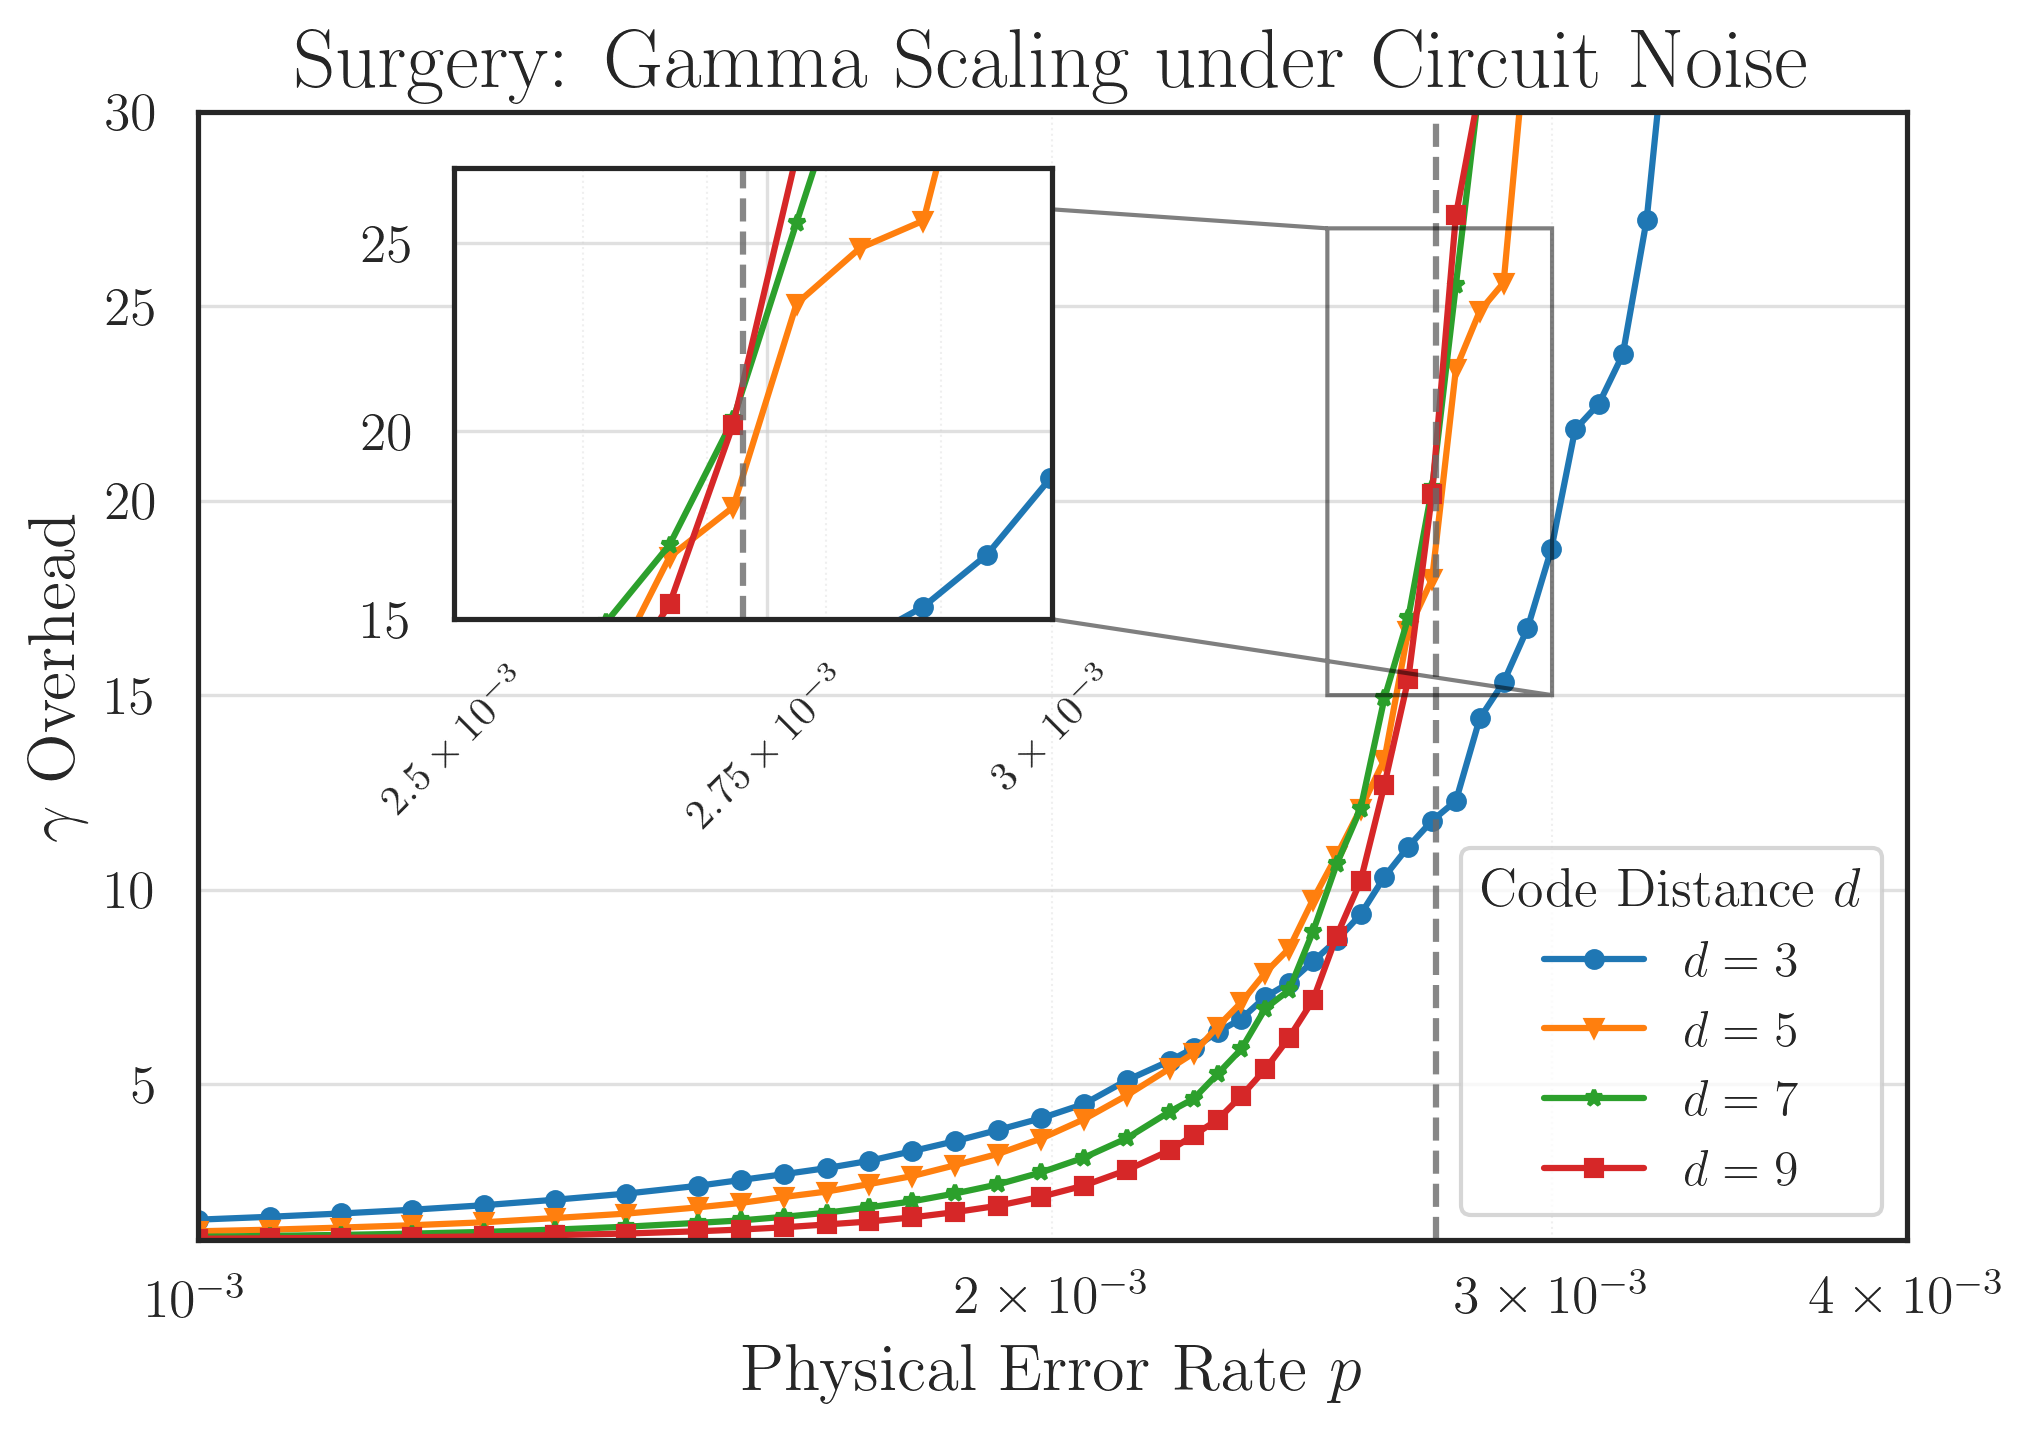

In [269]:
# Define the threshold
THRESHOLD_P = 2.73e-3

# 1. Load the data
df = pd.read_csv('../data/gamma_surgery.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'],
        group['gamma'],
        **DIST_STYLE[distance],
        markersize=4,
        label=rf"$d={distance}$",
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 30.0)
ax.set_xlim(1e-3, 4e-3)
ax.set_xscale('log') 
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.set_title("Surgery: Gamma Scaling under Circuit Noise", fontsize=20)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"$\gamma$ Overhead")

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend placed in the lower right
ax.legend(title="Code Distance $d$", loc='lower right')

# 4. Inset Plot for the Threshold Zoom
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the data onto the inset axes
for distance, group in df.groupby('distance'):
    axins.plot(
        group['physical_error_probability'],
        group['gamma'],
        **DIST_STYLE[distance],
        markersize=4,
        label=rf"$d={distance}$",
    )

# Formatting the inset
axins.set_xscale('log')

# Zoomed limits for x (around p = 2.73e-3)
axins.set_xlim(2.5e-3, 3e-3)
axins.set_ylim(15.0, 27.0) 

axins.set_xticks([2.5e-3, 2.75e-3, 3e-3])
axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())

# 3. Rotate the labels 45 degrees and slightly reduce font size to ensure they fit
axins.tick_params(axis='x', rotation=45, labelsize=10)
# ----------------------------------------------

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_surgery_d3579.pdf", bbox_inches='tight')

plt.show()

In [270]:
# Calculate the infidelities around the threshold for the d=7,9 memory cases

# Load the matrices for d=3,5,7,9
ptm_d3_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d3_CircuitNoise.npy")
ptm_d5_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d7_CircuitNoise.npy")
ptm_d9_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d9_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.concatenate([
    np.geomspace(1e-5, 1e-3, 10),    # 10 points logscaling
    np.linspace(1.1e-3, 1e-2, 40),   # 40 dense linear points
])

ptm_d3_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d3_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d9_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d9_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 4
    print(ptm_ideal.T @ ptm_noisy)

    return 1 - fidelity

# Calculate infidelities for d=3,5,7,9
infidelities_d3 = [calculate_infidelity(ptm_d3_ideal, ptm_noisy) for ptm_noisy in ptm_d3_noisy]
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]
infidelities_d9 = [calculate_infidelity(ptm_d9_ideal, ptm_noisy) for ptm_noisy in ptm_d9_noisy]

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1.      0.      0.      0.     ]
 [0.      1.      0.      0.     ]
 [0.      0.      0.99995 0.     ]
 [0.      0.      0.      1.     ]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1.      0.      0.      0.     ]
 [0.      1.      0.      0.     ]
 [0.      0.      0.99995 0.     ]
 [0.      0.      0.      0.99995]]
[[1.      0.      0.      0.     ]
 [0.      0.99995 0.      0.     ]
 [0.      0.      0.99985 0.     ]
 [0.      0.      0.      0.99985]]
[[1.      0.      0.      0.     ]
 [0.      0.9997  0.      0.     ]
 [0.      0.      0.99975 0.     ]
 [0.      0.      0.      0.99985]]
[[1.      0.      0.      0.     ]
 [0.      0.99955 0.      0.     ]
 [0.      0.      0.99845 0.     ]
 [0.      0.      0.      0.99955]]
[[1.     0.     0.     0.    ]
 [0.     0.9985 0.     0.    ]
 [0.     0.     0.997  0.    ]
 [0.     0.     0. 

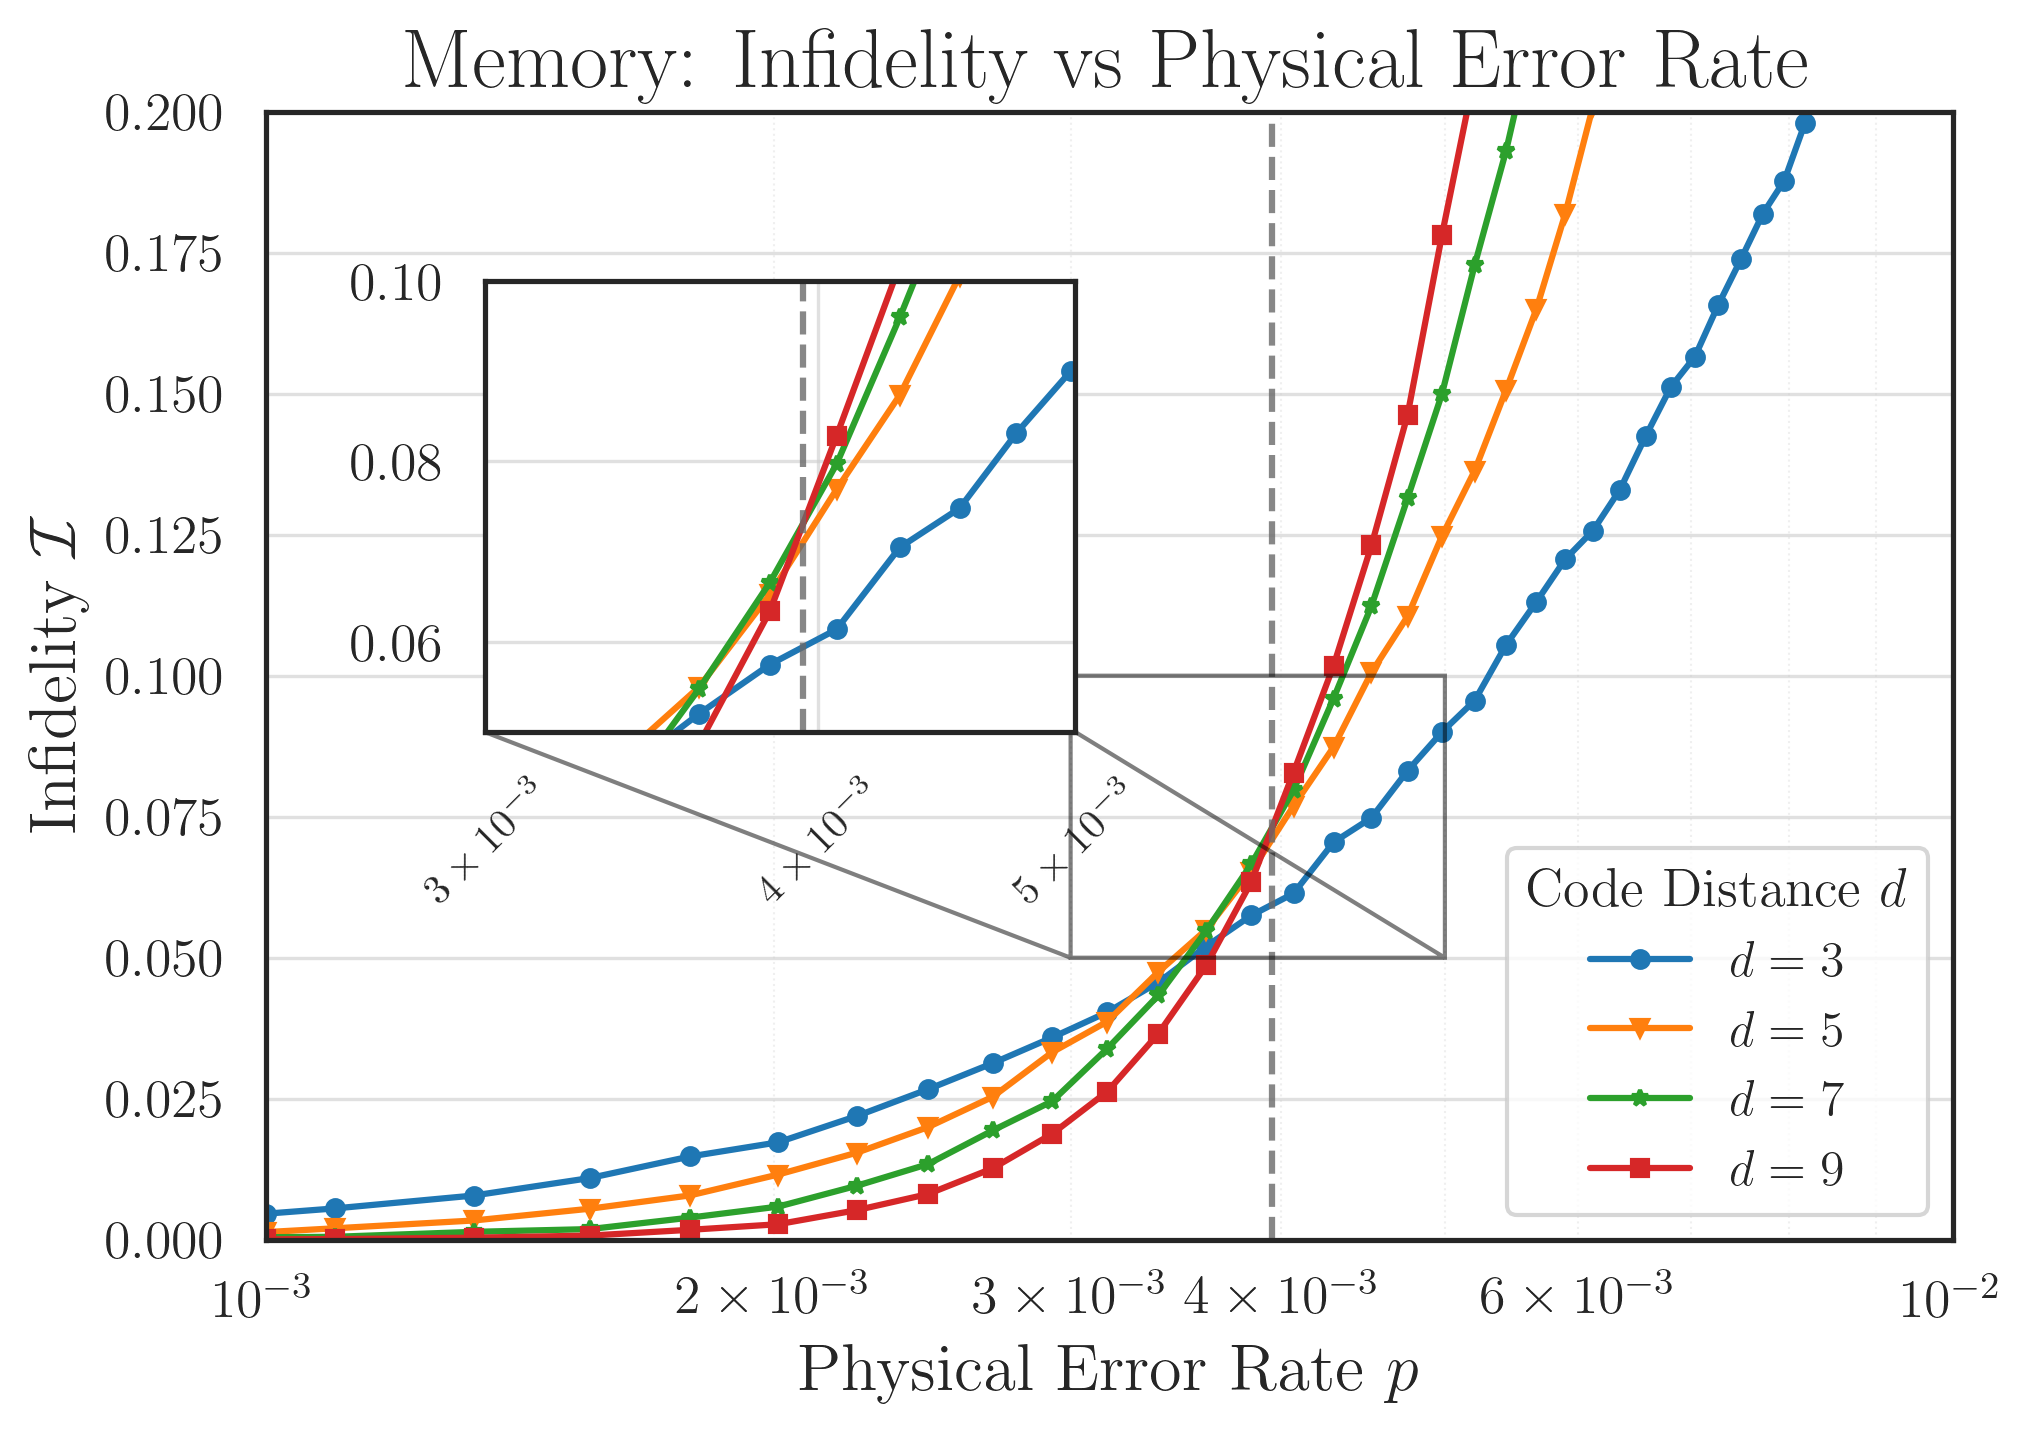

In [271]:
# Define the threshold
THRESHOLD_P = 3.95e-3

# Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Plot on the main axis
for (d, infidelities) in [(3, infidelities_d3), (5, infidelities_d5),
                           (7, infidelities_d7), (9, infidelities_d9)]:
    ax.plot(probs, infidelities, **DIST_STYLE[d],
            markersize=4, linestyle='-', label=rf"$d={d}$")

# Main Axis Formatting
ax.set_ylim(0, 0.2)
ax.set_xlim(1e-3, 1e-2)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.set_title('Memory: Infidelity vs Physical Error Rate', fontsize=20)
ax.set_xlabel('Physical Error Rate $p$')
ax.set_ylabel('Infidelity $\mathcal{I}$')

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend placed in the lower right
ax.legend(title="Code Distance $d$", loc='lower right')

# Inset Plot for the Threshold Zoom
# Placed in the upper left [x0, y0, width, height]
axins = ax.inset_axes([0.13, 0.45, 0.35, 0.4])

# Re-plot the exact same lines onto the inset axes
for (d, infidelities) in [(3, infidelities_d3), (5, infidelities_d5),
                           (7, infidelities_d7), (9, infidelities_d9)]:
    axins.plot(probs, infidelities, **DIST_STYLE[d],
            markersize=4, linestyle='-', label=rf"$d={d}$")

# Formatting the inset
axins.set_xscale('log')
axins.set_xticks([3e-3, 4e-3, 5e-3])
axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())
# Zoomed limits for x (around p = 4e-3)
axins.set_xlim(3e-3, 5e-3)
axins.set_ylim(0.05, 0.1) 

# 3. Rotate labels so the wider math-text labels don't crash into each other
axins.tick_params(axis='x', rotation=45, labelsize=10)
# ----------------------------------------------

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# Final output
fig.set_dpi(300)
plt.tight_layout()

# Save plot as PDF
plt.savefig("../plots/Memory_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()

In [272]:
def _debug_ptms(ptm):
    print(np.any(np.isnan(ptm)), np.any(np.isinf(ptm)))
    print(np.sum(np.isnan(ptm)), "NaNs,", np.sum(np.isinf(ptm)), "infs")

In [273]:
# Calculate the infidelities around the threshold for the d=7,9 memory cases

# Load the matrices for d=3,5,7,9
ptm_d3_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d3_CircuitNoise.npy")
ptm_d5_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d7_CircuitNoise.npy")
ptm_d9_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d9_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.concatenate([
    np.geomspace(1e-3, 1.5e-3, 8),    # sparse
    np.geomspace(1.5e-3, 2.2e-3, 12)[1:], # approaching the rise
    np.geomspace(2.2e-3, 3.5e-3, 25)[1:], # dense in the steep divergence zone (threshold)
    np.geomspace(3.5e-3, 1e-2, 8)[1:],    # sparse tail
])

ptm_d3_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d3_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d9_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d9_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1

    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16
        
    return 1 - fidelity

# Calculate infidelities for d=3,5,7,9
infidelities_d3 = [calculate_infidelity(ptm_d3_ideal, ptm_noisy) for ptm_noisy in ptm_d3_noisy]
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]
infidelities_d9 = [calculate_infidelity(ptm_d9_ideal, ptm_noisy) for ptm_noisy in ptm_d9_noisy]

########
# I guess this RuntimeWarning is due to relatively small entries for high noise in the gate logic entries
# or relatively small entries for small noise in the diagonal entries characterising the pauli noise. Either way
# they do not show up in the plot so I will keep it as is and a better infidelity calc could be implemented later...

/var/folders/9g/5y1bw0px0x74fc53vwv3xy800000gn/T/ipykernel_38982/1492966648.py:29: RuntimeWarning: divide by zero encountered in matmul
  fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16
/var/folders/9g/5y1bw0px0x74fc53vwv3xy800000gn/T/ipykernel_38982/1492966648.py:29: RuntimeWarning: overflow encountered in matmul
  fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16
/var/folders/9g/5y1bw0px0x74fc53vwv3xy800000gn/T/ipykernel_38982/1492966648.py:29: RuntimeWarning: invalid value encountered in matmul
  fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16


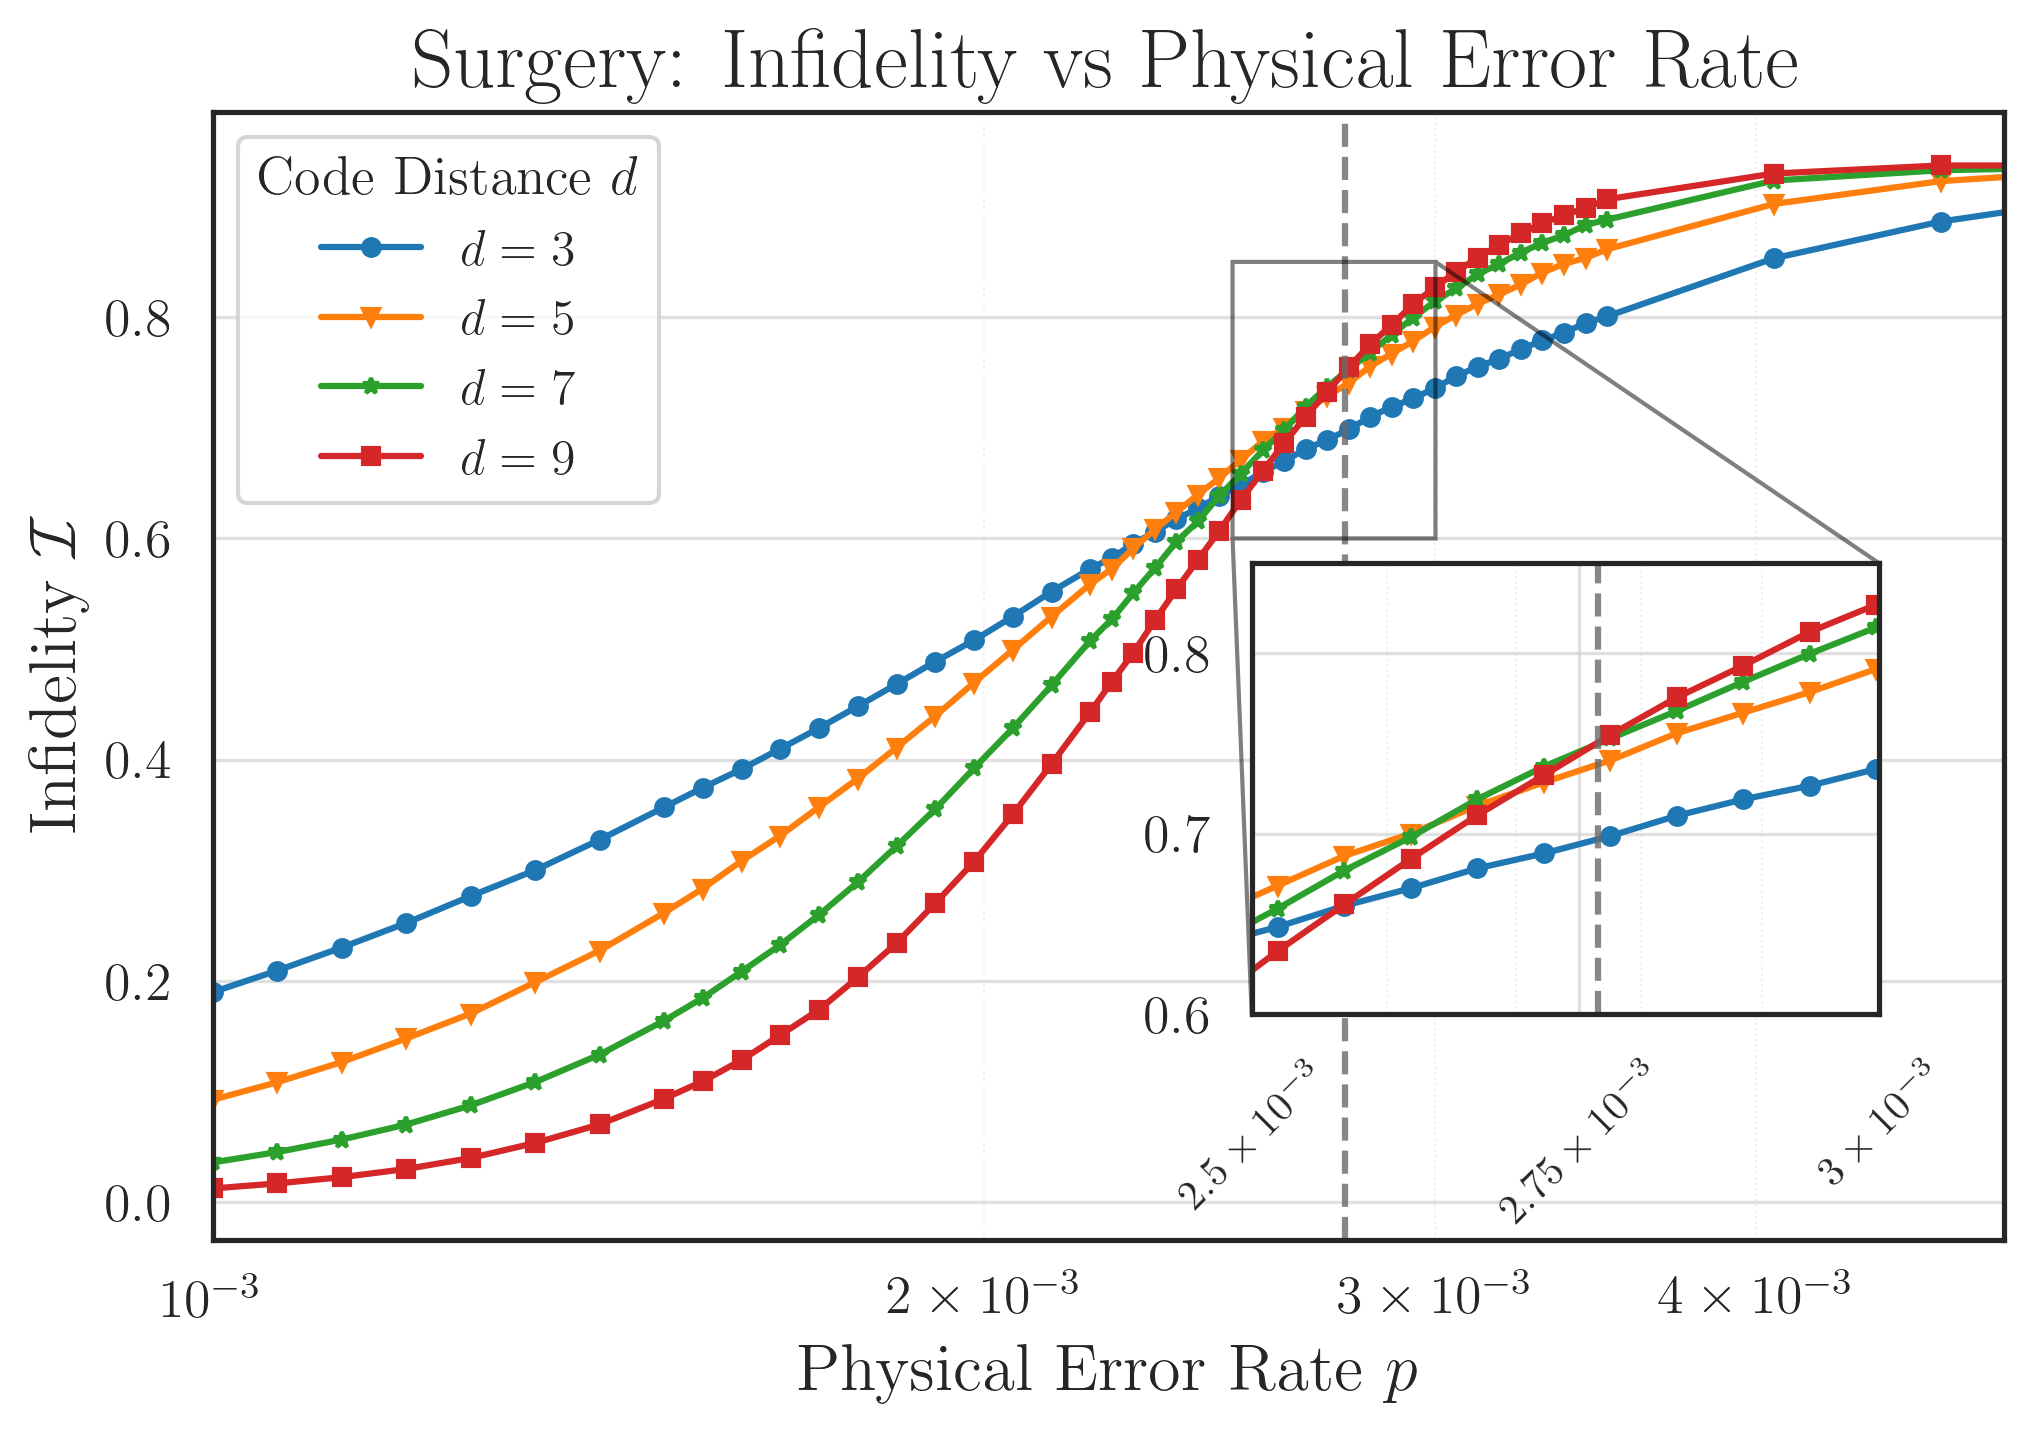

In [274]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Define the threshold
THRESHOLD_P = 2.765e-3

# Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Plot on the main axis
for (d, infidelities) in [(3, infidelities_d3), (5, infidelities_d5),
                           (7, infidelities_d7), (9, infidelities_d9)]:
    ax.plot(probs, infidelities, **DIST_STYLE[d],
            markersize=4, linestyle='-', label=rf"$d={d}$")

# Main Axis Formatting
ax.set_xlim(1e-3, 5e-3)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(LogFormatterMathtext())
ax.set_title('Surgery: Infidelity vs Physical Error Rate', fontsize=20)
ax.set_xlabel('Physical Error Rate $p$')
ax.set_ylabel('Infidelity $\mathcal{I}$')

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend placed in the lower right
ax.legend(title="Code Distance $d$", loc='upper left')

# Inset Plot for the Threshold Zoom
# Placed in the upper left [x0, y0, width, height]
axins = ax.inset_axes([0.58, 0.20, 0.35, 0.4])

# Re-plot the exact same lines onto the inset axes
for (d, infidelities) in [(3, infidelities_d3), (5, infidelities_d5),
                           (7, infidelities_d7), (9, infidelities_d9)]:
    axins.plot(probs, infidelities, **DIST_STYLE[d],
            markersize=4, linestyle='-', label=rf"$d={d}$")

# Formatting the inset
axins.set_xscale('log')

# Zoomed limits for x (centered around the 2.73e-3 threshold)
axins.set_xlim(2.5e-3, 3.0e-3)
axins.set_ylim(0.6, 0.85)

# --- FORMATTING FIX FOR SCIENTIFIC NOTATION ---
# 1. Set specific tick marks so they don't crowd
axins.set_xticks([2.5e-3, 2.75e-3, 3.0e-3])
axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())

# 3. Rotate labels 45 degrees so they fit cleanly
axins.tick_params(axis='x', rotation=45, labelsize=10)
# ----------------------------------------------

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# Final output
fig.set_dpi(300)
plt.tight_layout()

# Save plot as PDF
plt.savefig("../plots/Surgery_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()

In [275]:
# Defining Heat Map print function which I definetly wrote myself

def plot_ptm(matrix, title, save_name):
    # Ensure a completely clean white background template
    sns.set_theme(style="white")
    
    # Automatically adapt figure setup based on matrix size
    if matrix.shape[0] == 4:
        fig_size = (6, 5)
        width_ratios = [4, 0.3]
        pauli_labels = [r"$I$", r"$X$", r"$Y$", r"$Z$"]
        title_y = 1.12
        adj_top, adj_bottom, adj_left, adj_right = 0.85, 0.10, 0.12, 0.88
    elif matrix.shape[0] == 16:
        fig_size = (10, 9)
        width_ratios = [15, 0.6]
        pauli_labels = [
            r"$I_c I_t$", r"$I_c X_t$", r"$I_c Y_t$", r"$I_c Z_t$",
            r"$X_c I_t$", r"$X_c X_t$", r"$X_c Y_t$", r"$X_c Z_t$",
            r"$Y_c I_t$", r"$Y_c X_t$", r"$Y_c Y_t$", r"$Y_c Z_t$",
            r"$Z_c I_t$", r"$Z_c X_t$", r"$Z_c Y_t$", r"$Z_c Z_t$"
        ]
        title_y = 1.10
        adj_top, adj_bottom, adj_left, adj_right = 0.82, 0.08, 0.12, 0.92
    else:
        raise ValueError(f"Unsupported matrix size: {matrix.shape}. Expected 4x4 or 16x16.")

    # Create distinct axes for the heatmap and colorbar to prevent layout clipping
    fig, (ax, cbar_ax) = plt.subplots(
        1, 2, 
        figsize=fig_size, 
        facecolor='white',
        gridspec_kw={'width_ratios': width_ratios}
    )
    
    # Plot heatmap
    sns.heatmap(
        matrix, 
        ax=ax,
        cbar_ax=cbar_ax,
        annot=False, 
        cmap="bwr", 
        vmin=-1, 
        vmax=1, 
        center=0,
        square=True,
        linewidths=0.5,      
        linecolor="#b0b0b0"
    )
    
    # Snap the X-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # Apply labels and lock the alignment anchor so the text pivots perfectly
    ax.set_xticklabels(pauli_labels, rotation=45, ha="left", rotation_mode="anchor", fontsize=13)
    ax.set_yticklabels(pauli_labels, rotation=0, fontsize=13)
    
    # Strip tick lines, leave a tiny touch of padding for text breathing room
    ax.tick_params(axis='both', which='both', length=0, pad=6)
    cbar_ax.tick_params(length=0) 
    
    # Set clean colorbar ticks
    cbar_ax.set_yticks([-1, 0, 1])
    
    # Position the title
    ax.set_title(title, y=title_y, fontsize=26) 

    # Save plot as PDF
    plt.savefig(f"../plots/{save_name}.pdf", bbox_inches='tight')
    
    plt.show()

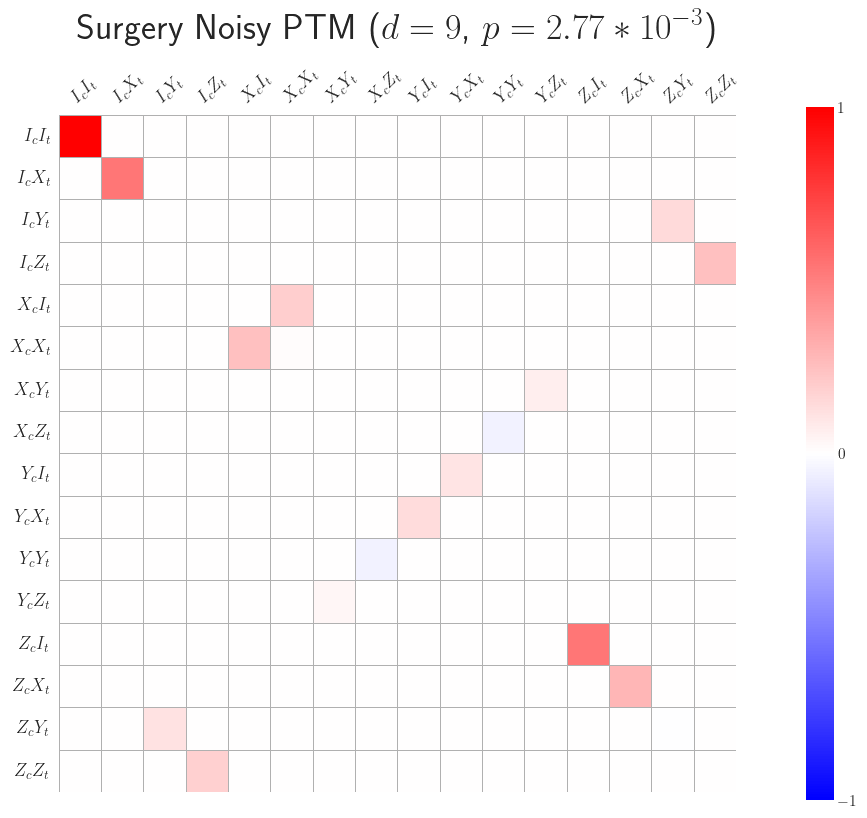

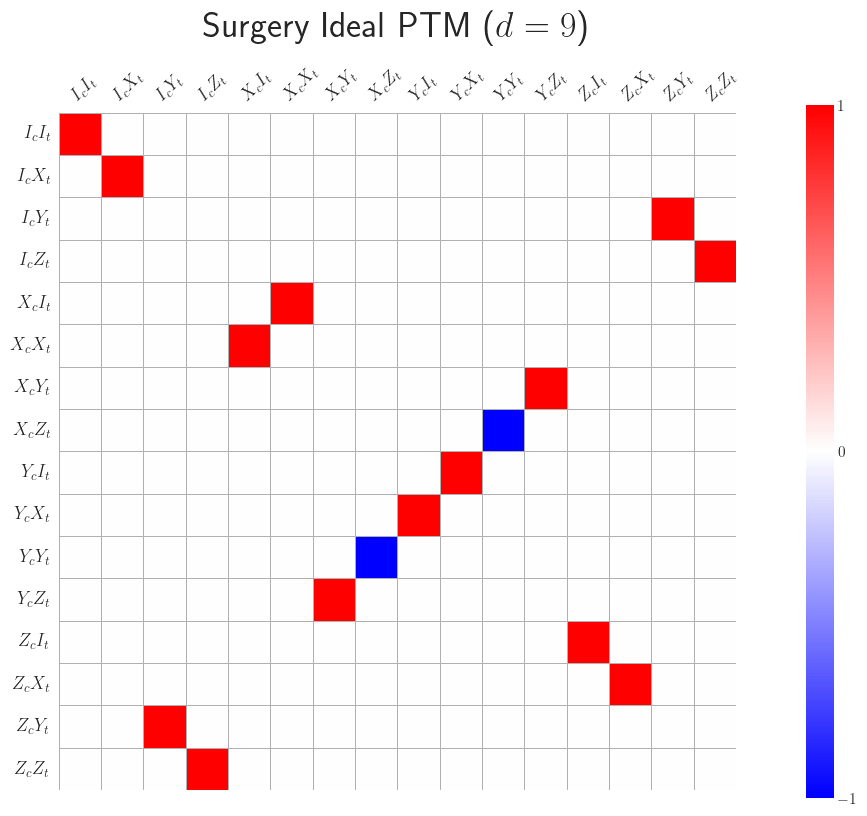

In [276]:
# Printing PTMs -> Noiseless Surgery and Memory Case

ptm_d9_ideal_surgery = np.load("../data/ptm_matrices_surgery/ptm_ideal_d9_CircuitNoise.npy")
ptm_d9_noisy_surgery = np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d9_p2.77e-03_CircuitNoise.npy")

# Plot both
plot_ptm(ptm_d9_noisy_surgery, "Surgery Noisy PTM ($d = 9$, $p = 2.77 * 10^{-3}$)", "surgery_ptm_heatmap_noisy")
plot_ptm(ptm_d9_ideal_surgery, "Surgery Ideal PTM ($d = 9$)", "surgery_ptm_heatmap_ideal")